In [3]:
import torch
torch.cuda.device_count()

0

In [4]:
import pandas as pd
df = pd.read_excel("C:/Users/ngyx/Desktop/Sanwa_forecast_new/data/100T-8 Parameter Data Y2025 to Y2026 Feb for AI Forecast 1.xlsx")


In [5]:
# 1) ensure it's a real datetime (important if it's currently a string)
df[df.columns[0]] = pd.to_datetime(df[df.columns[0]])

# 2) sort oldest -> latest
df = df.sort_values(by=df.columns[0], ascending=True).reset_index(drop=True)

In [6]:
cols = [
    "injection_time",
    "switchover_position",
    "max_injection_pressure",
    "switchover_pressure",
    "end_of_packing_stroke",
    "plastification_time",
    "nozzle_temperature",
    "barrel_front_temperature",
    "barrel_center_temperature",
    "barrel_rear_temperature",
    "feeder_temperature",
]

df = df[cols]
df

,injection_time,switchover_position,max_injection_pressure,switchover_pressure,end_of_packing_stroke,plastification_time,nozzle_temperature,barrel_front_temperature,barrel_center_temperature,barrel_rear_temperature,feeder_temperature
0,1.69,10.00,136.1,991,1.52,7.37,254.7,255.3,255.3,244.3,59.1
1,1.68,10.00,135.3,1035,2.17,7.36,255.4,255.1,255.2,243.7,59.7
2,1.69,10.00,139.3,1055,2.27,7.45,254.8,255.1,255.1,243.7,59.9
3,1.68,10.00,142.1,1067,1.96,7.52,255.1,255.1,254.9,243.8,59.1
4,1.69,10.00,144.3,1072,2.41,7.74,255.1,255.0,254.8,243.9,59.1
...,...,...,...,...,...,...,...,...,...,...,...
617425,1.83,8.00,160.4,1243,4.11,8.52,255.0,254.9,254.8,244.9,59.8
617426,1.83,7.99,159.8,1245,4.06,8.53,255.0,254.9,254.9,245.0,60.2
617427,1.83,7.99,160.1,1243,4.09,8.59,254.9,255.0,254.8,245.0,59.5
617428,1.83,8.00,160.0,1244,4.15,8.59,255.1,255.1,254.9,245.0,59.0


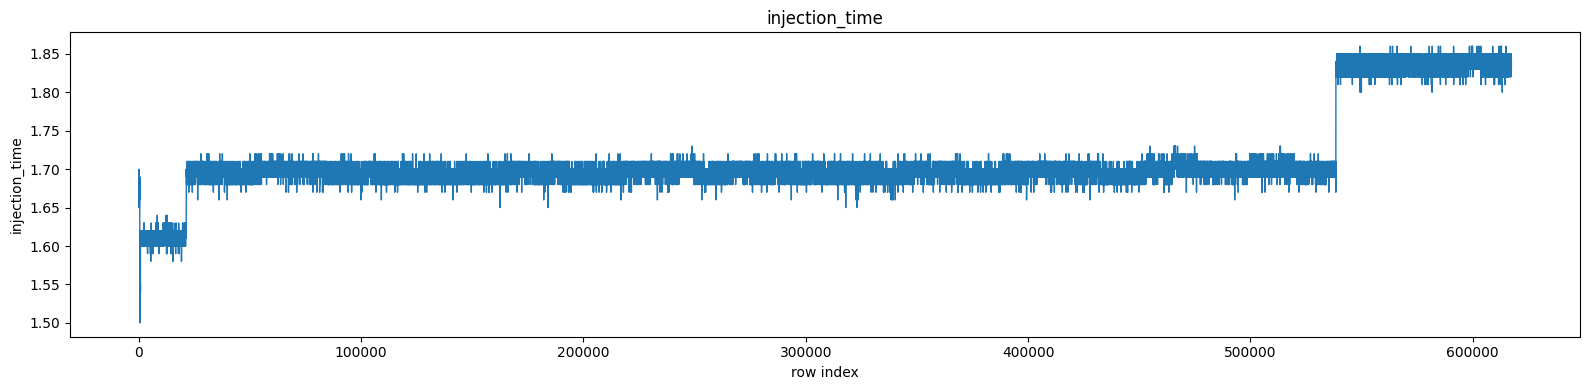

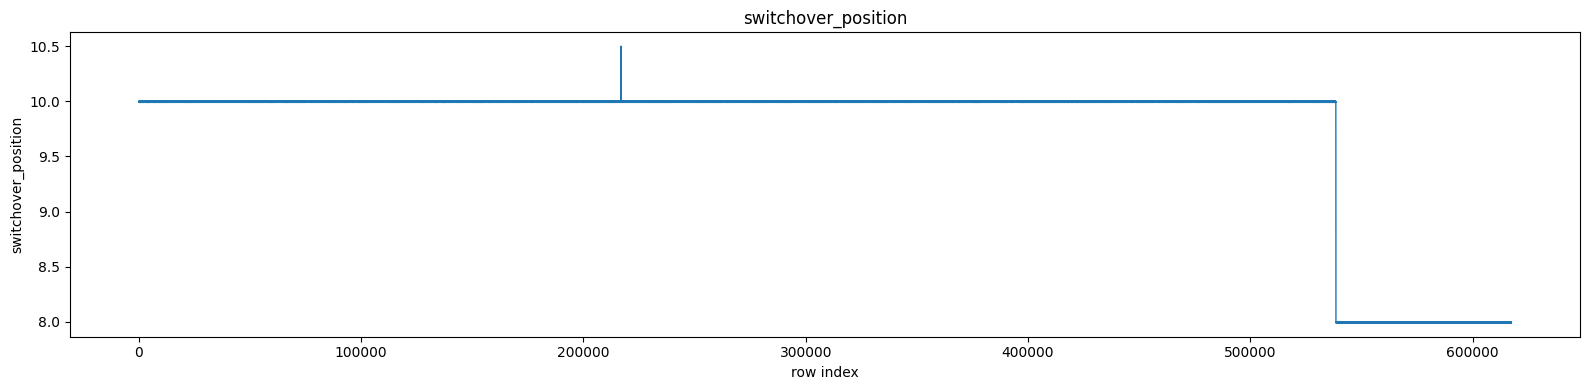

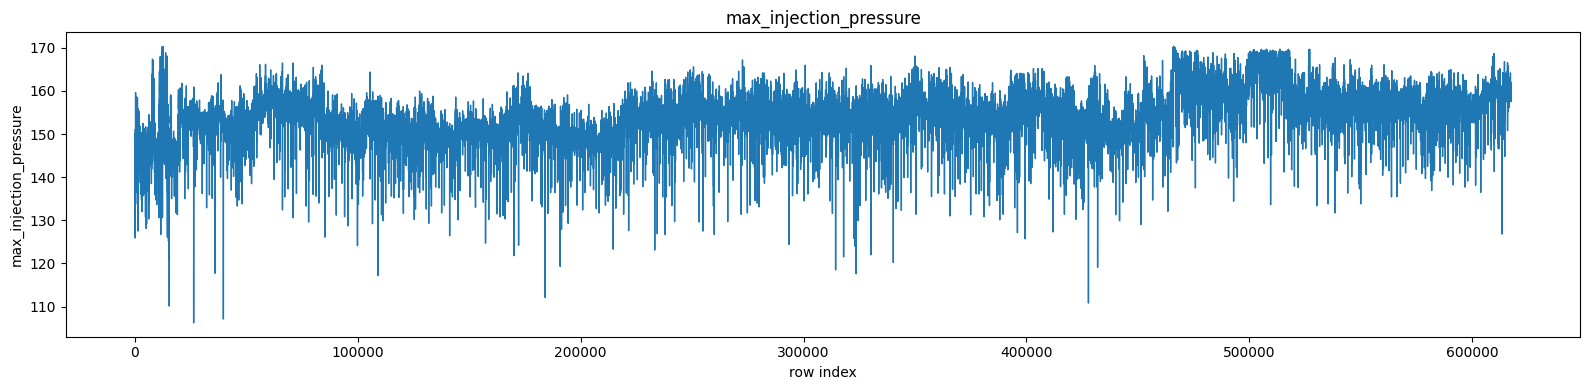

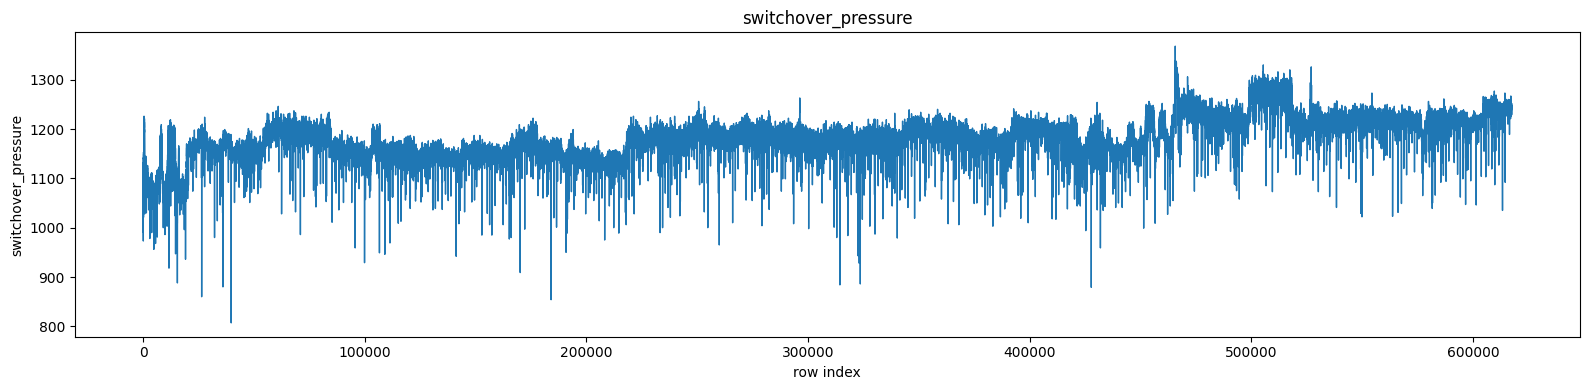

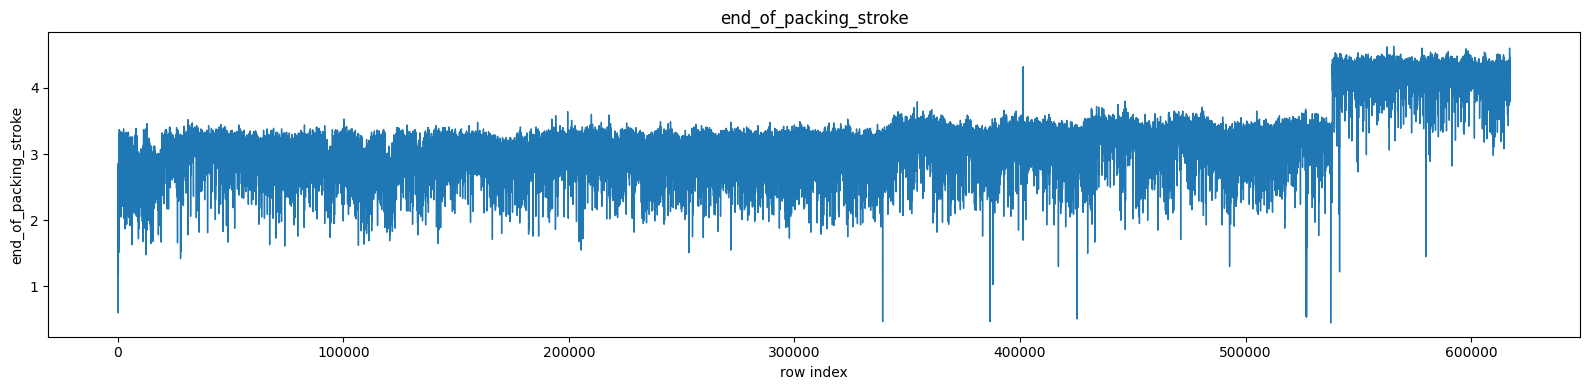

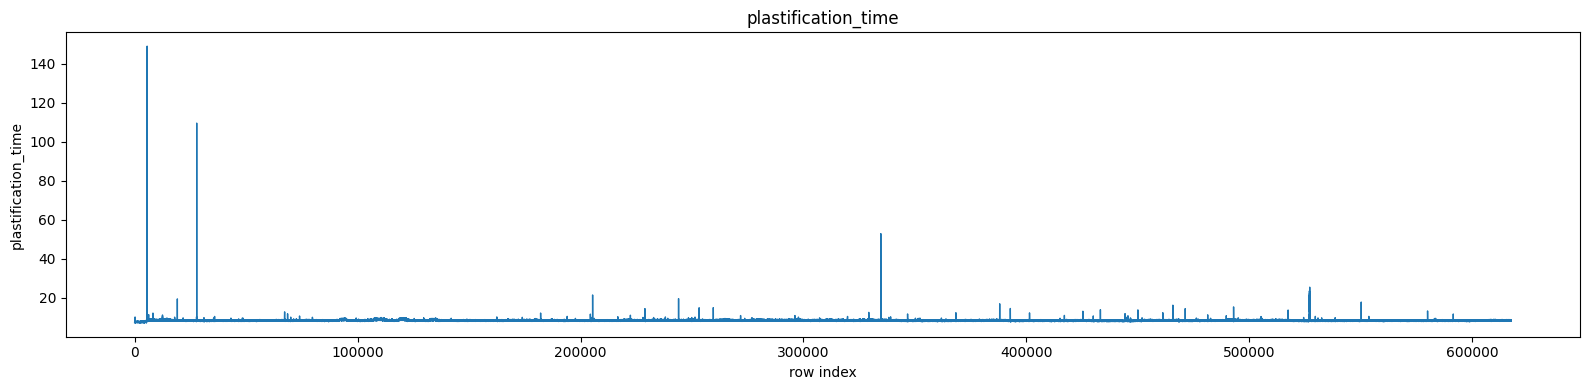

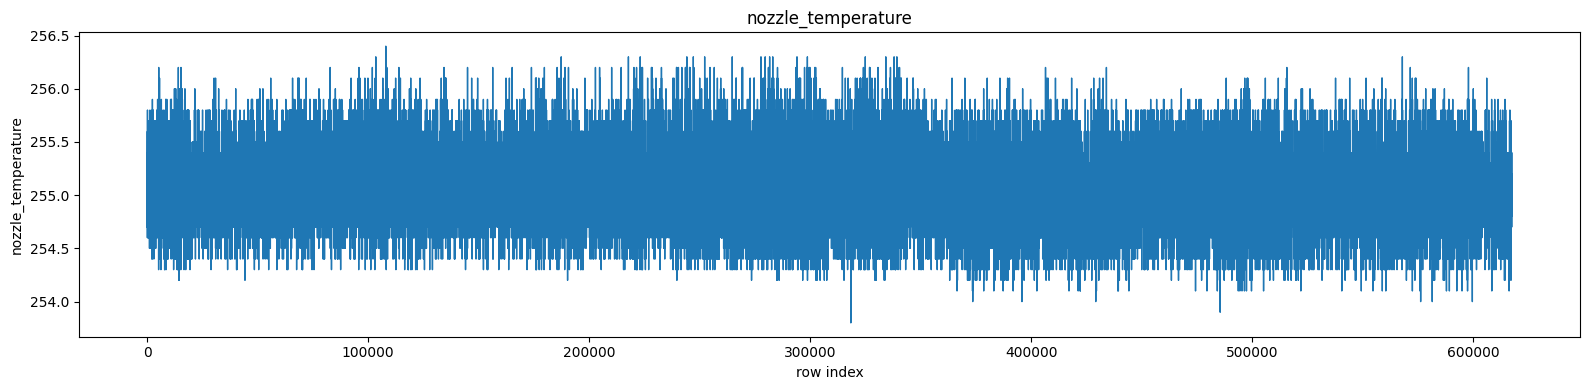

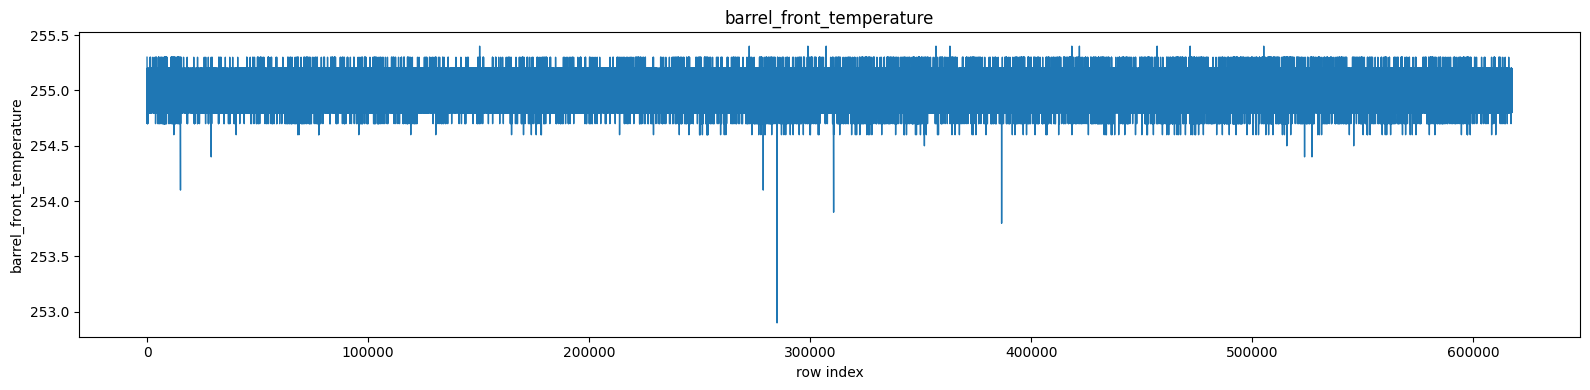

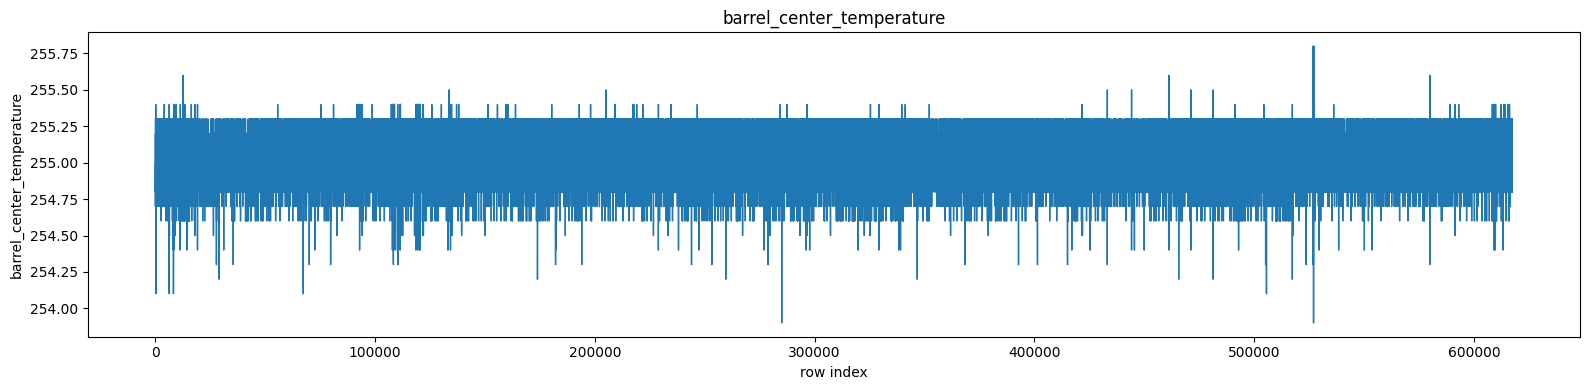

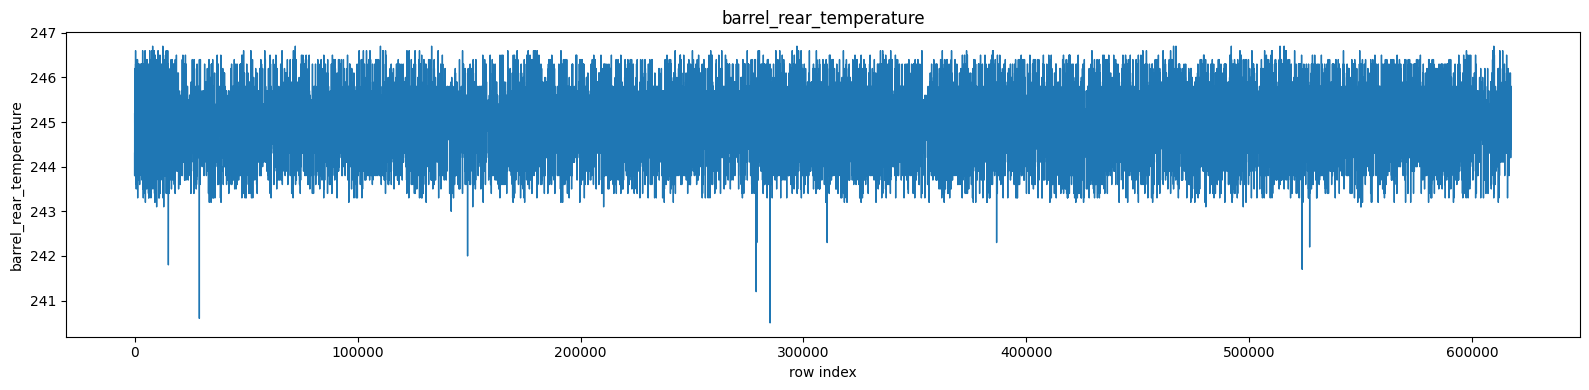

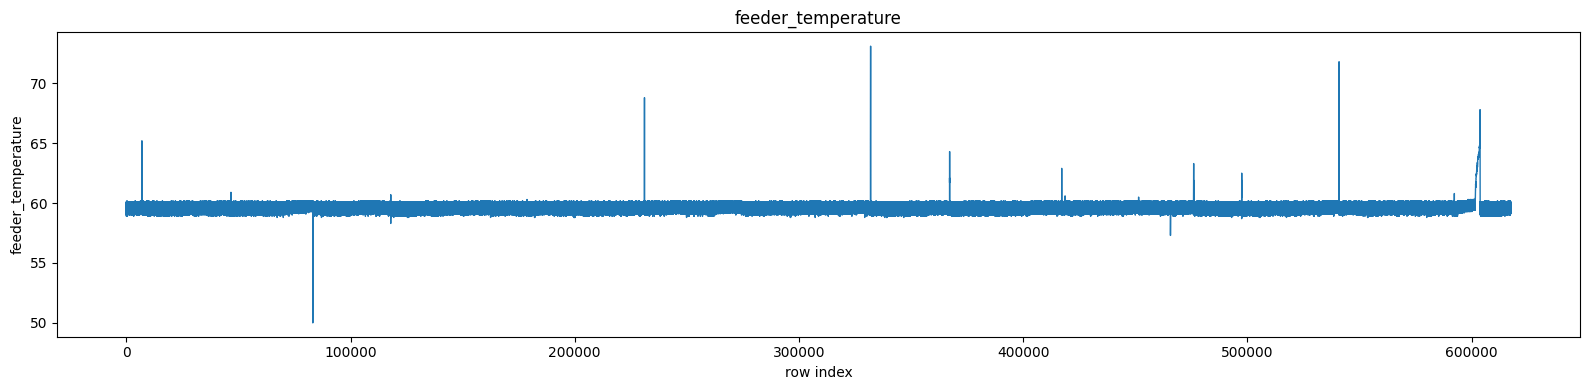

In [7]:
import numpy as np
import matplotlib.pyplot as plt

def plot_each_channel(
    df,
    cols=None,
    time_col=None,      # set to your timestamp column name if you have one (optional)
    max_points=200_000, # downsample target
    show=True,
    save_dir=None,      # e.g. "plots" to save PNGs
):
    if cols is None:
        cols = list(df.columns)

    # x-axis
    if time_col is not None and time_col in df.columns:
        x = df[time_col]
    else:
        x = df.index.to_numpy()

    N = len(df)
    stride = max(1, N // max_points)
    idx = np.arange(0, N, stride)

    x_ds = x.iloc[idx] if hasattr(x, "iloc") else x[idx]

    for c in cols:
        y = df[c].to_numpy()
        y_ds = y[idx]

        plt.figure(figsize=(16, 4))
        plt.plot(x_ds, y_ds, linewidth=1)
        plt.title(c)
        plt.xlabel(time_col if (time_col is not None and time_col in df.columns) else "row index")
        plt.ylabel(c)
        plt.tight_layout()

        if save_dir is not None:
            import os
            os.makedirs(save_dir, exist_ok=True)
            plt.savefig(f"{save_dir}/{c}.png", dpi=150, bbox_inches="tight")

        if show:
            plt.show()
        else:
            plt.close()

# usage
cols = [
    "injection_time",
    "switchover_position",
    "max_injection_pressure",
    "switchover_pressure",
    "end_of_packing_stroke",
    "plastification_time",
    "nozzle_temperature",
    "barrel_front_temperature",
    "barrel_center_temperature",
    "barrel_rear_temperature",
    "feeder_temperature",
]

plot_each_channel(df, cols=cols, max_points=200_000)
# or save:
# plot_each_channel(df, cols=cols, max_points=200_000, save_dir="plots", show=False)

In [8]:
import os
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq

def write_windows_option2_chrono_split(
    df: pd.DataFrame,
    feature_cols,
    out_dir: str,
    window_size: int = 1024,
    horizon: int = 50,
    train_ratio: float = 0.6,
    val_ratio: float = 0.2,
    batch_size: int = 2048,
    compression: str = "zstd",
    sort_by_time_col: str | None = None,
):
    """
    Option 2:
      1) Create ALL windows across full time series (streaming).
      2) Assign each window to train/val/test by where its *label horizon* lies
         w.r.t. raw row cut points. (No random split.)

    Parquet schema:
      - samples: FixedSizeList[float32] length = window_size * C
      - labels : FixedSizeList[float32] length = horizon * C
    """

    os.makedirs(out_dir, exist_ok=True)

    # 0) ensure chronological
    if sort_by_time_col is not None and sort_by_time_col in df.columns:
        df = df.sort_values(sort_by_time_col)

    # 1) keep only needed columns
    df = df.loc[:, feature_cols].dropna()
    arr = df.to_numpy(dtype=np.float32, copy=False)  # (N, C)
    N, C = arr.shape

    if N <= window_size + horizon:
        raise ValueError(f"Need N > window_size + horizon. Got N={N}, ws={window_size}, h={horizon}")

    # Raw-row cut points (chronological)
    cut1 = int(train_ratio * N)
    cut2 = int((train_ratio + val_ratio) * N)

    # Total possible window starts
    num_samples = N - window_size - horizon + 1  # start in [0, num_samples-1]

    X_list_size = window_size * C
    Y_list_size = horizon * C

    # Schema (ONLY samples + labels)
    schema = pa.schema([
        pa.field("samples", pa.list_(pa.float32(), X_list_size)),  # <-- FIX
        pa.field("labels",  pa.list_(pa.float32(), Y_list_size)),  # <-- FIX
    ])

    train_path = os.path.join(out_dir, "train_1p.parquet")
    val_path   = os.path.join(out_dir, "val.parquet")
    test_path  = os.path.join(out_dir, "test.parquet")

    train_writer = pq.ParquetWriter(train_path, schema=schema, compression=compression)
    val_writer   = pq.ParquetWriter(val_path,   schema=schema, compression=compression)
    test_writer  = pq.ParquetWriter(test_path,  schema=schema, compression=compression)

    n_train = n_val = n_test = n_skip = 0

    try:
        for start0 in range(0, num_samples, batch_size):
            end0 = min(start0 + batch_size, num_samples)
            count = end0 - start0

            # Need enough future rows to build X and Y for this batch
            chunk = arr[start0 : end0 + window_size + horizon - 1]  # (count + ws + h - 1, C)

            # X windows: (count, ws, C)
            Xw = np.lib.stride_tricks.sliding_window_view(
                chunk, window_shape=window_size, axis=0
            )[:count]

            # Y windows: (count, h, C) from chunk[ws:]
            Yw = np.lib.stride_tricks.sliding_window_view(
                chunk[window_size:], window_shape=horizon, axis=0
            )[:count]

            starts = np.arange(start0, end0, dtype=np.int64)
            y_start = starts + window_size
            y_end   = y_start + horizon - 1

            # Split masks (labels must be fully inside split segment)
            m_train = (y_end < cut1)
            m_val   = (y_start >= cut1) & (y_end < cut2)
            m_test  = (y_start >= cut2)  # y_end is always < N by construction

            m_keep = m_train | m_val | m_test
            n_skip += int((~m_keep).sum())  # boundary-crossing horizons get skipped

            def write_split(mask, writer):
                nonlocal n_train, n_val, n_test
                if not mask.any():
                    return

                X_sel = Xw[mask]  # (k, ws, C)
                Y_sel = Yw[mask]  # (k, h,  C)
                k = X_sel.shape[0]

                # Flatten with (time, channel) order => length ws*C / h*C
                x_flat = X_sel.reshape(k, X_list_size)
                y_flat = Y_sel.reshape(k, Y_list_size)

                x_arr = pa.FixedSizeListArray.from_arrays(
                    pa.array(x_flat.reshape(-1), type=pa.float32()),
                    list_size=X_list_size,
                )
                y_arr = pa.FixedSizeListArray.from_arrays(
                    pa.array(y_flat.reshape(-1), type=pa.float32()),
                    list_size=Y_list_size,
                )

                tbl = pa.Table.from_arrays([x_arr, y_arr], names=["samples", "labels"])
                writer.write_table(tbl)

                if writer is train_writer:
                    n_train += k
                elif writer is val_writer:
                    n_val += k
                else:
                    n_test += k

            write_split(m_train, train_writer)
            write_split(m_val,   val_writer)
            write_split(m_test,  test_writer)

    finally:
        train_writer.close()
        val_writer.close()
        test_writer.close()

    print("[DONE]")
    print(f"Raw rows: N={N}, C={C}")
    print(f"Cut points (raw idx): train< {cut1}, val< {cut2}, test>= {cut2}")
    print(f"Windows total possible: {num_samples}")
    print(f"Saved train: {n_train}")
    print(f"Saved val  : {n_val}")
    print(f"Saved test : {n_test}")
    print(f"Skipped (boundary-crossing horizons): {n_skip}")
    print("Out dir:", out_dir)
    return train_path, val_path, test_path


# ===== Example usage in your notebook =====
cols = [
    "injection_time",
    "switchover_position",
    "max_injection_pressure",
    "switchover_pressure",
    "end_of_packing_stroke",
    "plastification_time",
    "nozzle_temperature",
    "barrel_front_temperature",
    "barrel_center_temperature",
    "barrel_rear_temperature",
    "feeder_temperature",
]
train_p, val_p, test_p = write_windows_option2_chrono_split(
    df=df,
    feature_cols=cols,
    out_dir="splits_h50_chrono_option2",
    window_size=1024,
    horizon=50,
    train_ratio=0.6,
    val_ratio=0.2,
    batch_size=2048,
    compression="zstd",
    sort_by_time_col=None,  # or your timestamp col if you have one
)

[DONE]
Raw rows: N=617430, C=11
Cut points (raw idx): train< 370458, val< 493944, test>= 493944
Windows total possible: 616357
Saved train: 369385
Saved val  : 123437
Saved test : 123437
Skipped (boundary-crossing horizons): 98
Out dir: splits_h50_chrono_option2


In [2]:
import pandas as pd
df = pd.read_parquet("splits_h50_chrono_option2/test.parquet")
df

,samples,labels
0,"[1.66, 1.66, 1.67, 1.68, 1.67, 1.68, 1.67, 1.6...","[1.7, 1.7, 1.71, 1.69, 1.69, 1.7, 1.7, 1.7, 1...."
1,"[1.66, 1.67, 1.68, 1.67, 1.68, 1.67, 1.67, 1.6...","[1.7, 1.71, 1.69, 1.69, 1.7, 1.7, 1.7, 1.69, 1..."
2,"[1.67, 1.68, 1.67, 1.68, 1.67, 1.67, 1.68, 1.6...","[1.71, 1.69, 1.69, 1.7, 1.7, 1.7, 1.69, 1.7, 1..."
3,"[1.68, 1.67, 1.68, 1.67, 1.67, 1.68, 1.67, 1.6...","[1.69, 1.69, 1.7, 1.7, 1.7, 1.69, 1.7, 1.7, 1...."
4,"[1.67, 1.68, 1.67, 1.67, 1.68, 1.67, 1.67, 1.6...","[1.69, 1.7, 1.7, 1.7, 1.69, 1.7, 1.7, 1.7, 1.7..."
...,...,...
123432,"[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8...","[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8..."
123433,"[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8...","[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8..."
123434,"[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8...","[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8..."
123435,"[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8...","[1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.83, 1.8..."


# Prediction and Plot

In [9]:
import numpy as np

pred_path = "C:/Users/ngyx/Desktop/Sanwa_forecast_new/result/test_preds.npy"
true_path = "C:/Users/ngyx/Desktop/Sanwa_forecast_new/result/test_targets.npy"
orig_path = "C:/Users/ngyx/Desktop/Sanwa_forecast_new/result/test_orig_row.npy"


pred = np.load(pred_path)   # expect (N,C,H) or (N,H,C)
true = np.load(true_path)
orig = np.load(orig_path)

# --- if accidentally saved as (N,H,C), fix it ---
if pred.shape[1] == 50 and pred.shape[2] == 11:
    pred = pred.transpose(0, 2, 1)  # -> (N,11,50)
if true.shape[1] == 50 and true.shape[2] == 11:
    true = true.transpose(0, 2, 1)

# --- sort by orig_row for chronological order ---
order = np.argsort(orig)
pred = pred[order]
true = true[order]
orig = orig[order]

pred.shape, true.shape, orig.shape

((123437, 11, 50), (123437, 11, 50), (123437,))

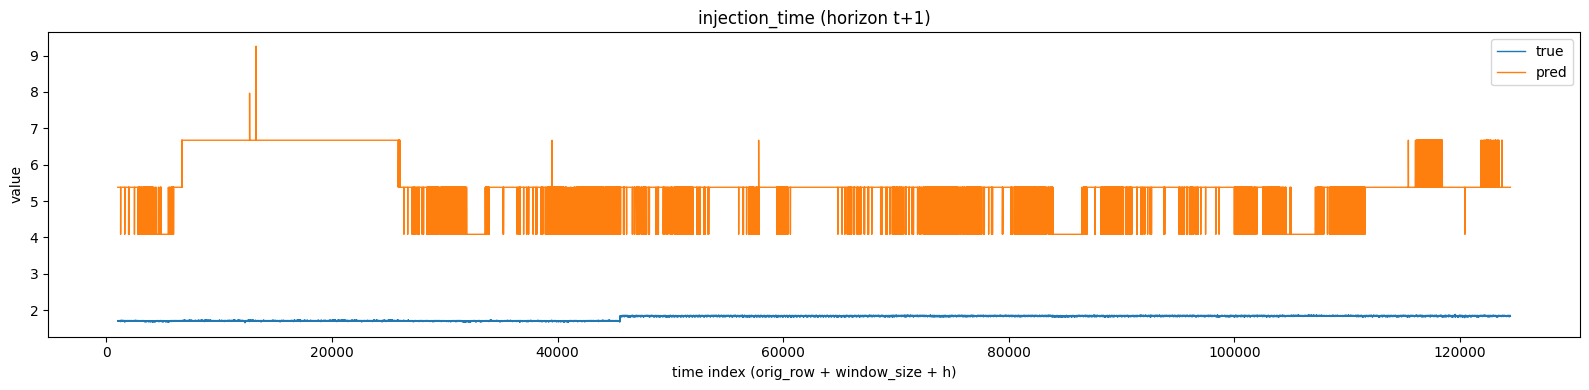

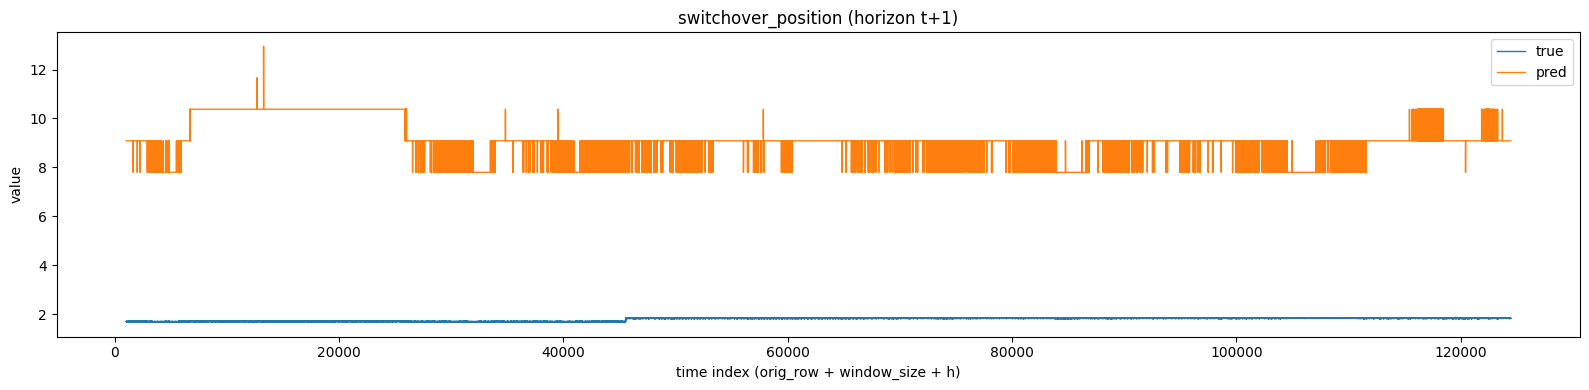

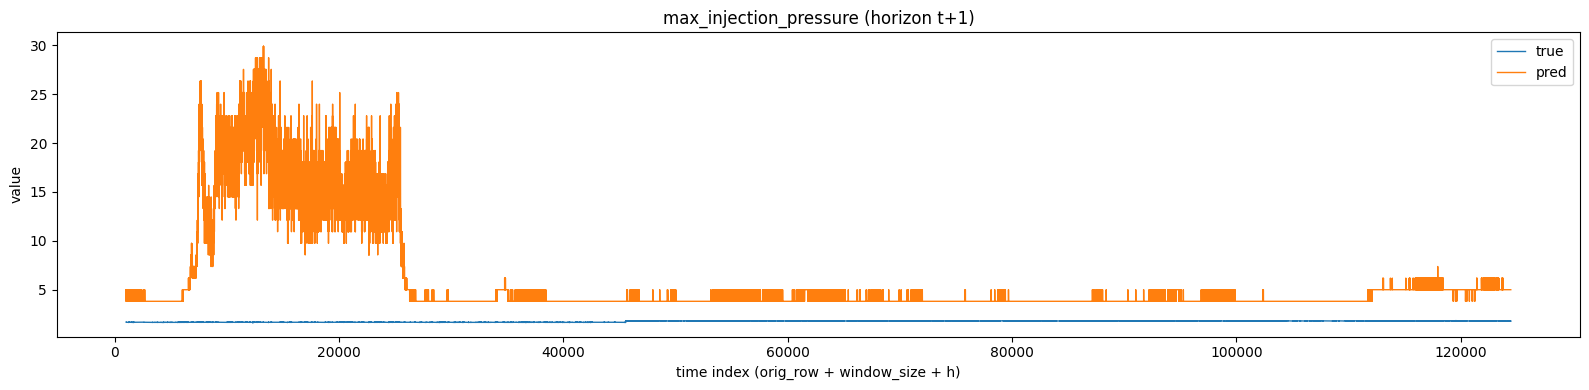

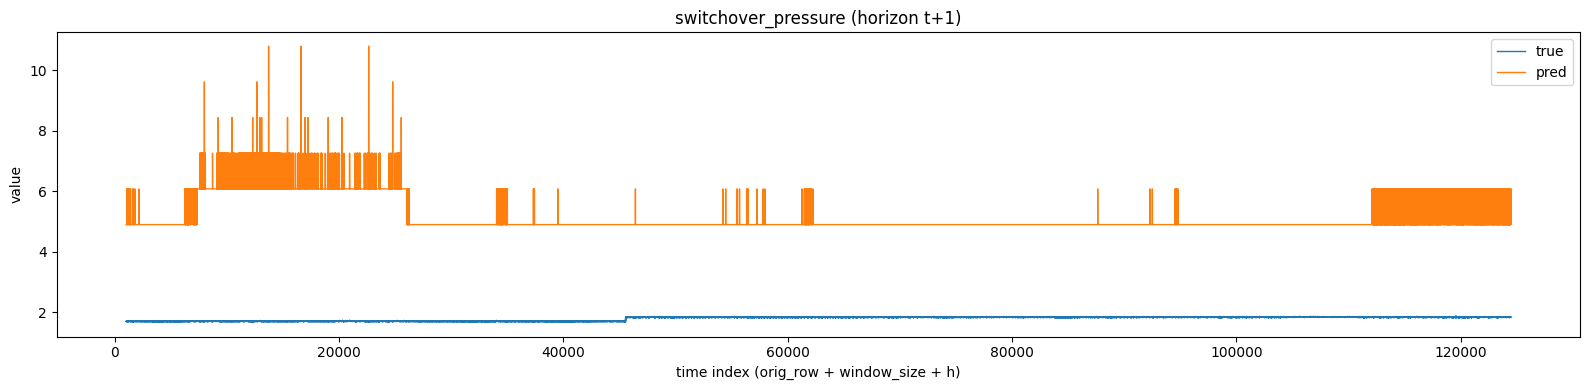

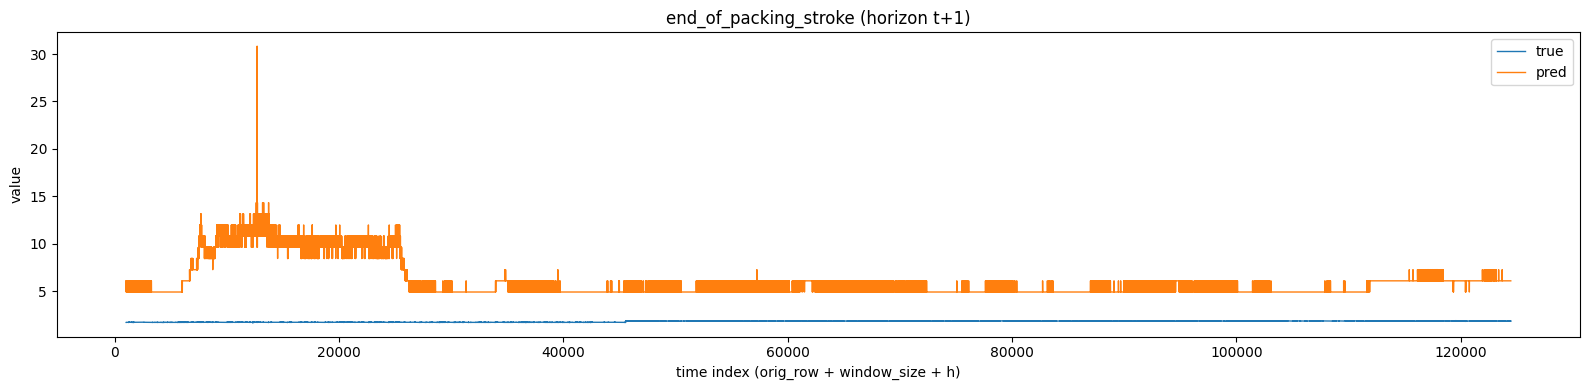

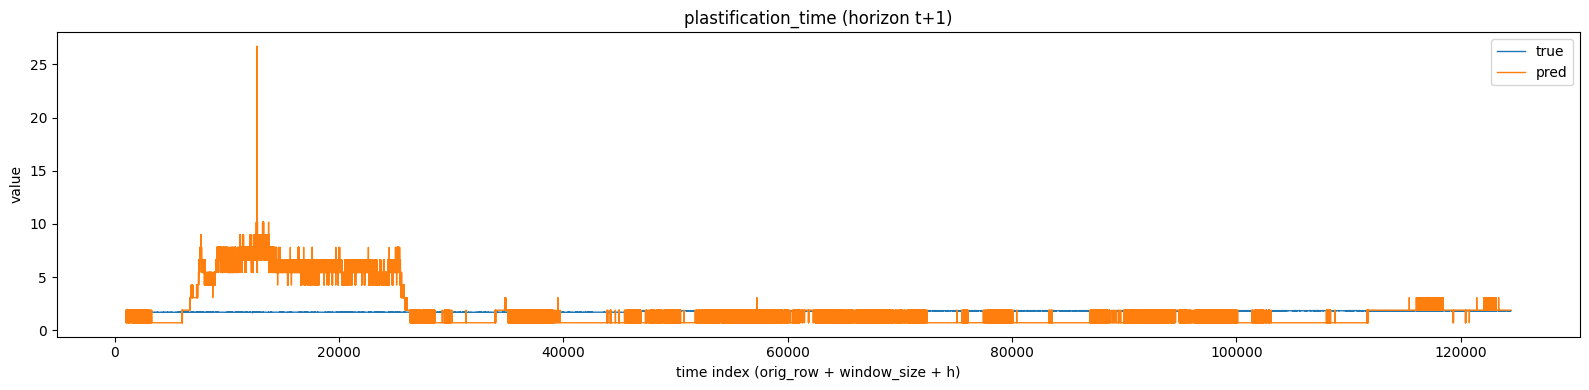

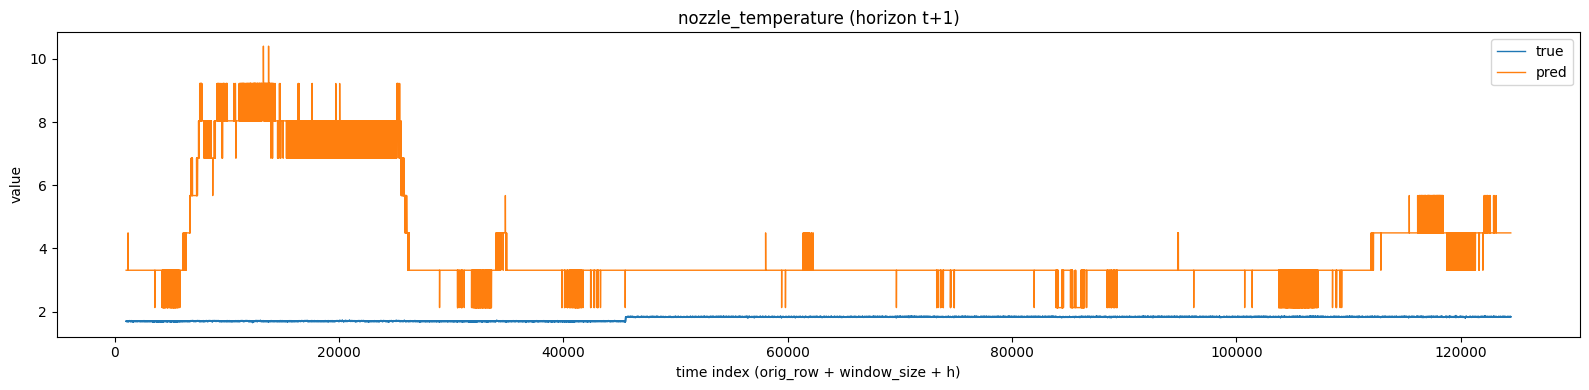

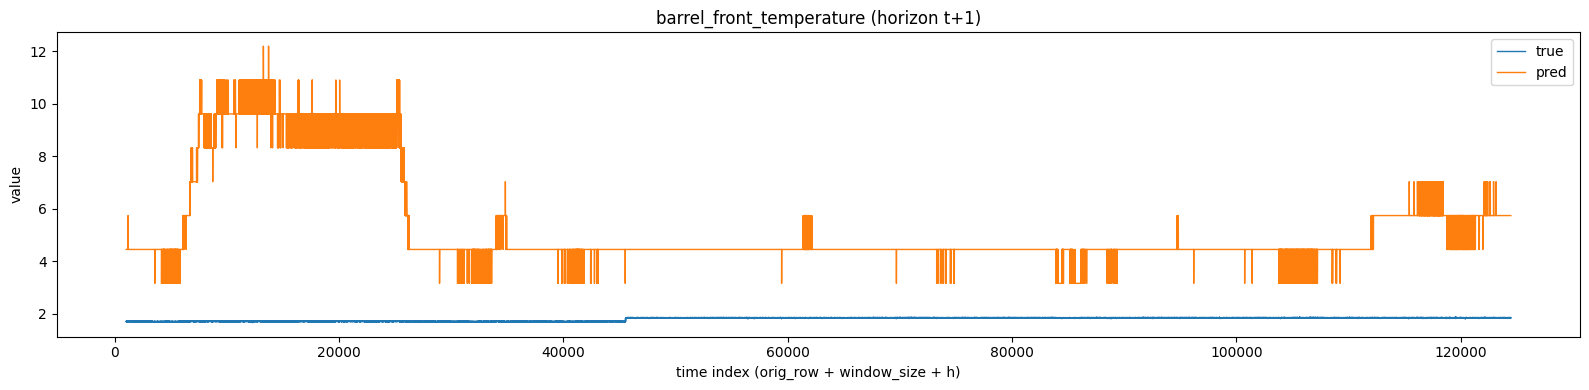

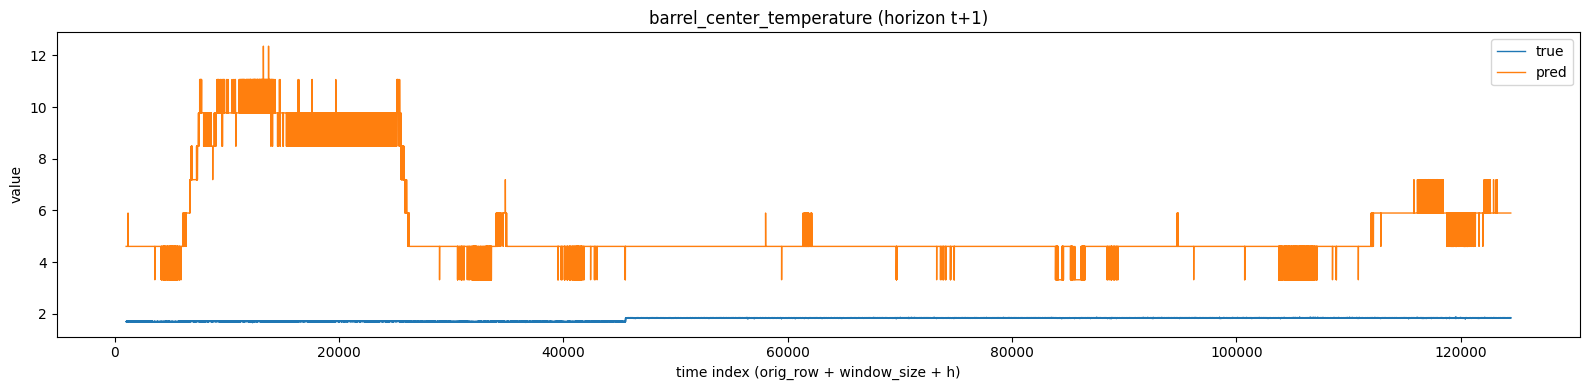

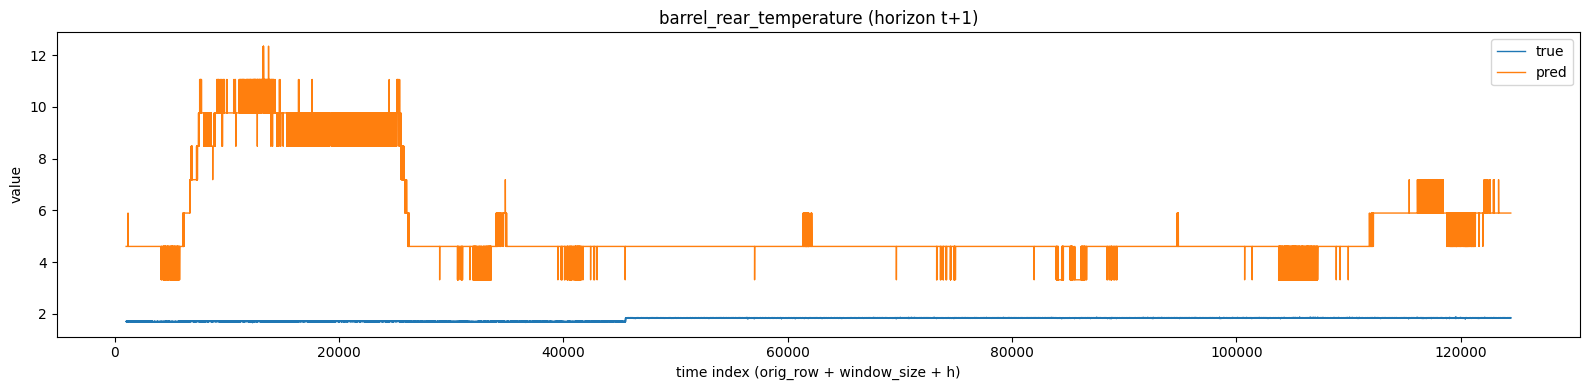

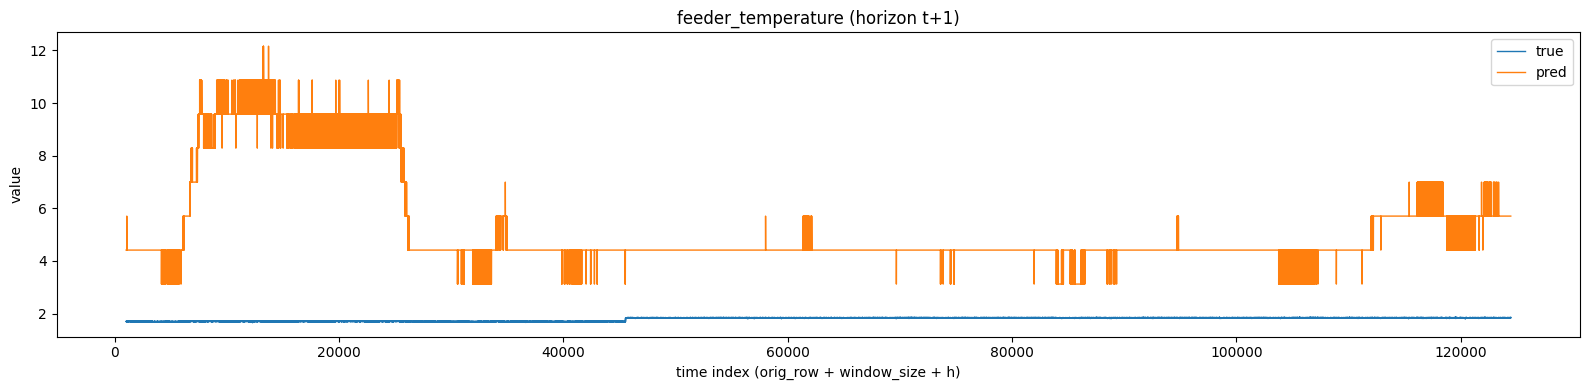

In [10]:
import matplotlib.pyplot as plt

cols = [
    "injection_time",
    "switchover_position",
    "max_injection_pressure",
    "switchover_pressure",
    "end_of_packing_stroke",
    "plastification_time",
    "nozzle_temperature",
    "barrel_front_temperature",
    "barrel_center_temperature",
    "barrel_rear_temperature",
    "feeder_temperature",
]

WINDOW_SIZE = 1024
h = 0  # 0 = t+1 (first step in horizon)

# x-axis in "raw time index" (approx): window_start + window_size + h
t = orig + WINDOW_SIZE + h

# downsample so plotting is fast
max_points = 200_000
stride = max(1, len(t) // max_points)
t_ds = t[::stride]

for ch, name in enumerate(cols):
    y_true = true[::stride, ch, h]
    y_pred = pred[::stride, ch, h]

    plt.figure(figsize=(16,4))
    plt.plot(t_ds, y_true, label="true", linewidth=1)
    plt.plot(t_ds, y_pred, label="pred", linewidth=1)
    plt.title(f"{name} (horizon t+{h+1})")
    plt.xlabel("time index (orig_row + window_size + h)")
    plt.ylabel("value")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [12]:
import numpy as np
import pandas as pd

# Load original test data
test_path = "splits_h50_chrono_option2/test.parquet"
test_pq = pd.read_parquet(test_path)

print("=== ORIGINAL TEST DATA (from parquet) ===")
print(f"Shape: {test_pq.shape}")
print(f"Columns: {test_pq.columns.tolist()}")
print(f"\nChannel stats from original df:")
cols = [
    "injection_time",
    "switchover_position",
    "max_injection_pressure",
    "switchover_pressure",
    "end_of_packing_stroke",
    "plastification_time",
    "nozzle_temperature",
    "barrel_front_temperature",
    "barrel_center_temperature",
    "barrel_rear_temperature",
    "feeder_temperature",
]
for i, col in enumerate(cols):
    if col in test_pq.columns:
        vals = test_pq[col].values
        print(f"  {i}: {col:40s} | min={vals.min():8.2f} max={vals.max():8.2f} mean={vals.mean():8.2f}")

# Load saved npy files
print("\n=== SAVED NPY FILES (from model) ===")
pred_path = "C:/Users/ngyx/Desktop/Sanwa_forecast_new/result/test_preds.npy"
true_path = "C:/Users/ngyx/Desktop/Sanwa_forecast_new/result/test_targets.npy"

try:
    pred = np.load(pred_path)
    true = np.load(true_path)
    
    print(f"Pred shape: {pred.shape}")
    print(f"True shape: {true.shape}")
    
    print(f"\nSaved pred channel stats (horizon step 0):")
    for ch in range(pred.shape[1]):
        vals = pred[:, ch, 0]  # first horizon step
        print(f"  {ch}: min={vals.min():8.2f} max={vals.max():8.2f} mean={vals.mean():8.2f}")
    
    print(f"\nSaved true channel stats (horizon step 0):")
    for ch in range(true.shape[1]):
        vals = true[:, ch, 0]
        print(f"  {ch}: min={vals.min():8.2f} max={vals.max():8.2f} mean={vals.mean():8.2f}")
        
except FileNotFoundError as e:
    print(f"ERROR: {e}")

print("\n=== DIAGNOSIS ===")
print("If the ranges are WILDLY different (e.g., true in 0-100 but pred in -5 to 5),")
print("it means normalization was NOT properly inverted in the saved arrays.")
print("This typically happens when norm_stats weren't loaded correctly during test pass.")


=== ORIGINAL TEST DATA (from parquet) ===
Shape: (123437, 2)
Columns: ['samples', 'labels']

Channel stats from original df:

=== SAVED NPY FILES (from model) ===
Pred shape: (123437, 11, 50)
True shape: (123437, 11, 50)

Saved pred channel stats (horizon step 0):
  0: min=    4.08 max=    9.26 mean=    5.37
  1: min=    7.80 max=   12.96 mean=    9.08
  2: min=    3.84 max=   29.89 mean=    6.02
  3: min=    4.89 max=   10.79 mean=    5.17
  4: min=    4.89 max=   30.83 mean=    6.04
  5: min=    0.71 max=   26.71 mean=    1.86
  6: min=    2.13 max=   10.40 mean=    4.11
  7: min=    3.15 max=   12.20 mean=    5.32
  8: min=    3.31 max=   12.35 mean=    5.48
  9: min=    3.31 max=   12.35 mean=    5.48
  10: min=    3.12 max=   12.16 mean=    5.29

Saved true channel stats (horizon step 0):
  0: min=    1.65 max=    1.88 mean=    1.78
  1: min=    1.65 max=    1.88 mean=    1.78
  2: min=    1.65 max=    1.88 mean=    1.78
  3: min=    1.65 max=    1.88 mean=    1.78
  4: min=    1.

In [15]:

# DEEP DIVE: Unpack the actual parquet FixedSizeList data
import pyarrow.parquet as pq
import numpy as np

print("\n=== UNPACKING PARQUET FIXEDSIZELIST DATA ===")
test_pq_path = "splits_h50_chrono_option2/test.parquet"
pf = pq.ParquetFile(test_pq_path)

# Read just first batch to inspect
batch = pf.read_row_group(0, columns=["labels"])
labels_col = batch.column(batch.schema.get_field_index("labels"))

print(f"Labels column type: {labels_col.type}")
print(f"Labels list_size: {labels_col.type.list_size}")  # should be horizon * C = 50 * 11 = 550

# ChunkedArray: combine chunks
labels_array = labels_col.combine_chunks()
vals = labels_array.values.to_numpy(zero_copy_only=False)
print(f"Values shape: {vals.shape}")
print(f"First 5 values from first sample: {vals[:5]}")

# Check if all values in first sample are same
first_sample = vals[:550]  # first window's label (H*C values)
print(f"\nFirst complete label window (all 550 values):")
print(f"  min={first_sample.min():.4f} max={first_sample.max():.4f} mean={first_sample.mean():.4f}")
print(f"  Unique values count: {len(np.unique(first_sample))}")

# Reshape to (H, C) and check per-channel
y_first = first_sample.reshape(50, 11)
print(f"\nFirst sample reshaped to (50, 11) - per-channel stats:")
for ch in range(11):
    ch_vals = y_first[:, ch]
    print(f"  Channel {ch:2d}: min={ch_vals.min():8.3f} max={ch_vals.max():8.3f} mean={ch_vals.mean():8.3f}")



=== UNPACKING PARQUET FIXEDSIZELIST DATA ===
Labels column type: fixed_size_list<element: float>[550]
Labels list_size: 550
Values shape: (356400,)
First 5 values from first sample: [1.7  1.7  1.71 1.69 1.69]

First complete label window (all 550 values):
  min=1.6900 max=1244.0000 mean=225.1258
  Unique values count: 150

First sample reshaped to (50, 11) - per-channel stats:
  Channel  0: min=   1.700 max=1230.000 mean= 232.795
  Channel  1: min=   1.700 max=1238.000 mean= 236.362
  Channel  2: min=   1.700 max=1226.000 mean= 211.327
  Channel  3: min=   1.690 max=1227.000 mean= 216.233
  Channel  4: min=   1.690 max=1233.000 mean= 216.576
  Channel  5: min=   1.690 max=1244.000 mean= 213.604
  Channel  6: min=   1.700 max=1228.000 mean= 212.947
  Channel  7: min=   1.700 max=1229.000 mean= 234.275
  Channel  8: min=   1.690 max=1223.000 mean= 234.151
  Channel  9: min=   1.700 max=1228.000 mean= 234.100
  Channel 10: min=   1.700 max=1228.000 mean= 234.013


In [17]:

# CHECK NORM STATS
import torch
import os

print("\n=== CHECKING NORM STATS ===")
checkpoint_dir = r"C:\Users\ngyx\Desktop\Sanwa_forecast_new\result"
norm_stats_path = os.path.join(checkpoint_dir, "norm_stats.pt")

if os.path.exists(norm_stats_path):
    stats = torch.load(norm_stats_path)
    print(f"✓ Found norm_stats.pt")
    print(f"Keys: {list(stats.keys())}")
    print(f"y_mode: {stats.get('y_mode', 'N/A')}")
    print(f"x_mode: {stats.get('x_mode', 'N/A')}")
    
    print(f"\nNormalization stats shapes:")
    for k, v in stats.items():
        if torch.is_tensor(v):
            print(f"  {k:10s}: shape={v.shape}, dtype={v.dtype}")
            if v.numel() <= 11:
                print(f"             values={v.flatten()[:11]}")
else:
    print(f"✗ ERROR: norm_stats.pt not found at:\n  {norm_stats_path}")



=== CHECKING NORM STATS ===
✓ Found norm_stats.pt
Keys: ['x_mode', 'y_mode', 'x_mean', 'x_std', 'y_mean', 'y_std']
y_mode: zscore
x_mode: zscore

Normalization stats shapes:
  x_mean    : shape=torch.Size([1, 11, 1]), dtype=torch.float32
             values=tensor([219.0634, 219.0715, 219.2113, 220.2005, 219.0646, 219.0700, 219.3108,
        219.3107, 219.3107, 219.3009, 219.1199])
  x_std     : shape=torch.Size([1, 11, 1]), dtype=torch.float32
             values=tensor([318.1591, 318.1537, 318.0933, 319.4595, 318.1579, 318.1544, 318.0883,
        318.0883, 318.0883, 318.0874, 318.1256])
  y_mean    : shape=torch.Size([1, 11, 1]), dtype=torch.float32
             values=tensor([226.6955, 229.5586, 206.2946, 211.2255, 211.2260, 207.5181, 207.6842,
        227.9455, 228.0555, 228.0539, 227.8528])
  y_std     : shape=torch.Size([1, 11, 1]), dtype=torch.float32
             values=tensor([331.3291, 330.0606, 303.0895, 301.8347, 301.8348, 302.5357, 302.4249,
        330.7287, 330.6549, 33

In [ ]:

# SIMULATE INVERSION TO FIND THE PROBLEM
import torch
import numpy as np

print("\n=== SIMULATING INVERT_Y LOGIC ===")

# Load the stats we just found
stats = torch.load(r"C:\Users\ngyx\Desktop\Sanwa_forecast_new\result\norm_stats.pt")
y_mean = stats["y_mean"]  # (1, 11, 1)
y_std = stats["y_std"]    # (1, 11, 1)

# Load the corrupted true values
true = np.load(r"C:\Users\ngyx\Desktop\Sanwa_forecast_new\result\test_targets.npy")
print(f"True shape: {true.shape}")  # should be (N, 11, 50)
print(f"True first sample, first channel, first timestep: {true[0, 0, 0]}")
print(f"All 6 values at [0, :, 0] (should be different per channel): {true[0, :, 0]}")

# Convert to tensor
y_norm = torch.from_numpy(true).float()

# Apply inversion (same logic as invert_y in the training script)
mode = stats["y_mode"]
print(f"\ny_mode: {mode}")

if mode == "zscore":
    print(f"\nApplying zscore inversion:")
    print(f"  y_mean shape: {y_mean.shape}")
    print(f"  y_std shape: {y_std.shape}")
    print(f"  y_norm shape: {y_norm.shape}")
    
    y_inverted = y_norm * y_std + y_mean
    print(f"  Result shape: {y_inverted.shape}")
    print(f"\nFirst sample, first channel, first timestep after inversion:")
    print(f"  {y_inverted[0, 0, 0]}")
    print(f"\nAll 6 channels at [0, :, 0] after inversion:")
    print(f"  {y_inverted[0, :, 0]}")
